# CS 672 / CRN 72938 Deep Learning
## Project 3: Computer Vision Transfer Learning with PyTorch and Tensorflow
## Student: Joshua Gottlieb
## Professor Tassos Sarbanes
## Date: 2025-12-12

# Load Libraries and Custom Functions

In [1]:
# Load libraries
import os
import pandas as pd
from torchinfo import summary

# Custom functions for evaluating model results
from modules.evaluation import combine_logs, get_predictions_and_metrics

# Custom functions for plotting
from modules.plotting import compare_confusion_matrices, plot_loss_curves

# Custom functions for preprocessing images and directories
from modules.preprocessing import load_image_datasets, train_test_split

# Custom functions for building and training models
from modules.training import compile_model, fit_model

2025-12-02 00:51:34.590848: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Data Preprocessing

Data is moved from the 5 given directories into train and test directories using a 75%/25% split.

In [ ]:
labels = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
data_dir = '../data'
raw_directories = [os.path.join(data_dir, label) for label in labels]
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

In [ ]:
# Split the data into train and test directories
train_test_split(
    directories = raw_directories,
    labels = labels,
    train_dir = train_dir,
    test_dir = test_dir,
    train_ratio = 0.75,
    seed = 42
)

Image preprocessing and augmentation is handled using Tensorflow's Dataset API or PyTorch's DataLoader API, as needed. Images are automatically resized based on the pre-trained backbone requirements. For ResNet50 and VGG16, the images are resized to (224, 224, 3) and for InceptionV3, the images are resized to (299, 299, 3). Each input is preprocessed using the appropriate helper functions in Tensorflow and PyTorch as outlined in the Tensorflow and PyTorch documentation.

```
# TensorFlow preprocessing functions
if framework == "tensorflow":
    if architecture == "resnet50":
        return resnet50.preprocess_input
    elif architecture == "inceptionv3":
        return inception_v3.preprocess_input
    elif architecture == "vgg16":
        return vgg16.preprocess_input

# PyTorch preprocessing using ImageNet normalization
elif framework == "pytorch":
    if architecture in ["resnet50", "vgg16", "inceptionv3"]:
        return transforms.Normalize(
            mean = [0.485, 0.456, 0.406],
            std = [0.229, 0.224, 0.225]
        )
```

Rather than creating additional images for augmentation, augmentation is handled automatically at the batch level. The augmentation transformations performed include: horizontal flipping, rotation by up to 45 degrees, and 20% adjustment in brightness and contrast. The first two augmentations help the models become spatially and rotationally invariant, while the latter two augmentations help the models become invariant to changes in luminance or color range.

Because these augmentations happen at the batch level, the models are not trained on additional images, as the images are changed as they are assigned to batches. This is different to augmenting the images by creating new images, which expands the training dataset. Image augmentations is only applied to the training data.

Tensorflow implementation of data augmentation:

```
tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),        # Random left-right flipping
        tf.keras.layers.RandomRotation(0.125),           # Rotate by ±45 degrees
        tf.keras.layers.RandomBrightness(factor = 0.2),  # Adjust brightness
        tf.keras.layers.RandomContrast(factor = 0.2),    # Adjust contrast
    ])
```

PyTorch implementation of data augmentation:

```
transforms.Compose([
        transforms.Resize(img_size),                     # Ensure uniform image size
        transforms.RandomHorizontalFlip(),               # Random left-right flipping
        transforms.RandomRotation(45),                   # Rotate by ±45 degrees
        transforms.ColorJitter(brightness = 0.2,
                               contrast = 0.2),          # Adjust brightness/contrast
    ])
```

# Model Training

Each model was loaded with pretrained weights with the final classification layer removed. Global average pooling was used, and then two fully connected layers with 256 neurons and ReLU activation were added. The final classification layer had 5 neurons (for the 5 classes) and used softmax predictions.

Each model was trained for 20 epochs using the Adam optimizer with default parameters.

Note that parameter counts differ between Tensorflow and PyTorch, as each framework counts the number of trainable parameters differently. Bias terms, convolutional layer padding, normalization layers, dropout/regularization layers, and activation functions all have different implementations in each framework, leading to different counts.

## ResNet50

The Residual Network (ResNet) architecture utilizes concatenation to pass identity copies of the data forward in the network to prevent network degradation. This allows the model to learn "residual mappings" and be much deeper than pure feedforward networks. ResNet was created in 2015. The ResNet50 model uses "blocks" of three convolutional layers with a passed residual connection at the end of each block. ResNet50 has 50 layers.

### Tensorflow

In [ ]:
# Define directory, architecture, and frameworks
data_dir = '../data'
architecture = 'resnet50'
framework = 'tensorflow'

In [ ]:
# Load and preprocess datasets
train, test, classes = load_image_datasets(
    data_dir = data_dir,
    architecture = architecture,
    framework = framework,
    batch_size = 32
)

In [ ]:
# Compile model
model = compile_model(
    architecture = architecture,
    framework = framework
)

The Tensorflow implementation of ResNet50 has 24,179,333 nontrainable parameters. The number of trainable parameters added is 591,621.

In [5]:
# Model summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,179,333 (92.24 MB)

 Trainable params: 591,621 (2.26 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Fit on Colab using GPU
history = fit_model(
    model = model,
    train = train,
    validation = test,
    epochs = 20,
    model_type = framework,
    model_name = f'{architecture}_{framework}',
    framework = framework
)

### PyTorch

In [ ]:
# Define directory, architecture, and frameworks
data_dir = '../data'
architecture = 'resnet50'
framework = 'pytorch'

In [ ]:
# Load and preprocess datasets
train, test, classes = load_image_datasets(
    data_dir = data_dir,
    architecture = architecture,
    framework = framework,
    batch_size = 32
)

In [ ]:
# Compile model
model = compile_model(
    architecture = architecture,
    framework = framework
)

The PyTorch implementation of ResNet50 has 24,099,653 nontrainable parameters. The number of trainable parameters added by the custom classification head is 591,621.

In [9]:
# Model summary
summary(model, (32, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 5]                   --
├─Conv2d: 1-1                            [32, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        (128)
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          (4,096)
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]   

In [ ]:
# Fit on Colab using GPU
history = fit_model(
    model = model,
    train = train,
    validation = test,
    epochs = 20,
    model_type = framework,
    model_name = f'{architecture}_{framework}',
    framework = framework
)

## VGG16

The VGG16 architecture is a simple feedforward CNN utilizing convolution and max pooling, followed by fully connected layers. The VGG16 model has 16 layers, 13 convolutional and 3 fully connected. The VGG architecture is unique compared to earlier architectures for using a simple, uniform convolutional architecture of 3x3 convolution filters and 2x2 max-pooling layers (compared to earlier work using much larger convolution filters). The VGG16 model was introduced in 2014 and is the earliest and simplest of the models tested in this project.

### Tensorflow

In [ ]:
# Define directory, architecture, and frameworks
data_dir = '../data'
architecture = 'vgg16'
framework = 'tensorflow'

In [ ]:
# Load and preprocess datasets
train, test, classes = load_image_datasets(
    data_dir = data_dir,
    architecture = architecture,
    framework = framework,
    batch_size = 32
)

In [ ]:
# Compile model
model = compile_model(
    architecture = architecture,
    framework = framework
)

The Tensorflow implementation of VGG16 has 14,913,093 nontrainable parameters. The number of trainable parameters added by the custom classification head is 198,405.

In [13]:
# Model summary
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,913,093 (56.89 MB)

 Trainable params: 198,405 (775.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Fit on Colab using GPU
history = fit_model(
    model = model,
    train = train,
    validation = test,
    epochs = 20,
    model_type = framework,
    model_name = f'{architecture}_{framework}',
    framework = framework
)

### PyTorch

In [ ]:
# Define directory, architecture, and frameworks
data_dir = '../data'
architecture = 'vgg16'
framework = 'pytorch'

In [ ]:
# Load and preprocess datasets
train, test, classes = load_image_datasets(
    data_dir = data_dir,
    architecture = architecture,
    framework = framework,
    batch_size = 32
)

In [ ]:
# Compile model
model = compile_model(
    architecture = architecture,
    framework = framework
)

The PyTorch implementation of VGG16 has 21,204,549 nontrainable parameters. The number of trainable parameters added by the custom classification head is 6,489,861, significantly higher than in the Tensorflow implementation. It is unclear why the PyTorch implementation differs here, as both models are implemented in similar fashion and this phenomenon does not occur in any of the other model types. It does not appear to have much, if any, effect on model training.

In [17]:
# Model summary
summary(model, (32, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [32, 5]                   --
├─Sequential: 1-1                        [32, 512, 7, 7]           --
│    └─Conv2d: 2-1                       [32, 64, 224, 224]        (1,792)
│    └─ReLU: 2-2                         [32, 64, 224, 224]        --
│    └─Conv2d: 2-3                       [32, 64, 224, 224]        (36,928)
│    └─ReLU: 2-4                         [32, 64, 224, 224]        --
│    └─MaxPool2d: 2-5                    [32, 64, 112, 112]        --
│    └─Conv2d: 2-6                       [32, 128, 112, 112]       (73,856)
│    └─ReLU: 2-7                         [32, 128, 112, 112]       --
│    └─Conv2d: 2-8                       [32, 128, 112, 112]       (147,584)
│    └─ReLU: 2-9                         [32, 128, 112, 112]       --
│    └─MaxPool2d: 2-10                   [32, 128, 56, 56]         --
│    └─Conv2d: 2-11                      [32, 256, 56, 56]   

In [ ]:
# Fit on Colab using GPU
history = fit_model(
    model = model,
    train = train,
    validation = test,
    epochs = 20,
    model_type = framework,
    model_name = f'{architecture}_{framework}',
    framework = framework
)

## InceptionV3

The Inception architecture uses convolutional filters of different sizes simultaneously to capture information at various scales. Each of these filter results are then concatenated together in an "Inception block". These blocks are combined together, along with "auxiliary classifiers" inserted partway into the model. The Inception architecture consists of 3 parts: the stem (data ingestion) consisting of a few convolutional layers, the body (data processing) consisting of many Inception modules, and finally the prediction head. InceptionV3 was released in 2016 and is the most complex of the architectures tested in this project.

### Tensorflow

In [ ]:
# Define directory, architecture, and frameworks
data_dir = '../data'
architecture = 'inceptionv3'
framework = 'tensorflow'

In [ ]:
# Load and preprocess datasets
train, test, classes = load_image_datasets(
    data_dir = data_dir,
    architecture = architecture,
    framework = framework,
    batch_size = 32
)

In [ ]:
# Compile model
model = compile_model(
    architecture = architecture,
    framework = framework
)

The Tensorflow implementation of InceptionV3 has 21,802,784 nontrainable parameters. The number of trainable parameters added is 591,621.

In [21]:
# Model summary
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,394,405 (85.43 MB)

 Trainable params: 591,621 (2.26 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# Fit on Colab using GPU
history = fit_model(
    model = model,
    train = train,
    validation = test,
    epochs = 20,
    model_type = framework,
    model_name = f'{architecture}_{framework}',
    framework = framework
)

### PyTorch

In [ ]:
# Define directory, architecture, and frameworks
data_dir = '../data'
architecture = 'inceptionv3'
framework = 'pytorch'

In [ ]:
# Load and preprocess datasets
train, test, classes = load_image_datasets(
    data_dir = data_dir,
    architecture = architecture,
    framework = framework,
    batch_size = 32
)

In [ ]:
# Compile model
model = compile_model(
    architecture = architecture,
    framework = framework
)

The PyTorch implementation of InceptionV3 has 25,112,264 nontrainable parameters. This is higher than the Tensorflow implementation due to some differences in how the BatchNorm2d layers are applied and due to slight difference in the structure of the Inception blocks. The number of trainable parameters added by the custom classification head is 591,621, just as in the Tensorflow implementation.

In [25]:
# Model summary
summary(model, (32, 3, 299, 299))

Layer (type:depth-idx)                   Output Shape              Param #
Inception3                               [32, 5]                   3,326,696
├─BasicConv2d: 1-1                       [32, 32, 149, 149]        --
│    └─Conv2d: 2-1                       [32, 32, 149, 149]        (864)
│    └─BatchNorm2d: 2-2                  [32, 32, 149, 149]        (64)
├─BasicConv2d: 1-2                       [32, 32, 147, 147]        --
│    └─Conv2d: 2-3                       [32, 32, 147, 147]        (9,216)
│    └─BatchNorm2d: 2-4                  [32, 32, 147, 147]        (64)
├─BasicConv2d: 1-3                       [32, 64, 147, 147]        --
│    └─Conv2d: 2-5                       [32, 64, 147, 147]        (18,432)
│    └─BatchNorm2d: 2-6                  [32, 64, 147, 147]        (128)
├─MaxPool2d: 1-4                         [32, 64, 73, 73]          --
├─BasicConv2d: 1-5                       [32, 80, 73, 73]          --
│    └─Conv2d: 2-7                       [32, 80, 73, 73]

In [ ]:
# Fit on Colab using GPU
history = fit_model(
    model = model,
    train = train,
    validation = test,
    epochs = 20,
    model_type = framework,
    model_name = f'{architecture}_{framework}',
    framework = framework
)

# Analysis

## Loss Curves for Each Model

Each of the training runs has a separate log file containing training and validation losses. These are combined into a single log dataframe for ease of comparison.

In [2]:
# Define logs directory
log_dir = '../logs'

# Combine logs from all training runs
logs = combine_logs(log_dir)
logs

,epoch,model,train_loss,val_loss
0,1,inceptionv3_pytorch,0.962743,0.546763
1,2,inceptionv3_pytorch,0.628470,0.488822
2,3,inceptionv3_pytorch,0.628573,0.408631
3,4,inceptionv3_pytorch,0.628081,0.475538
4,5,inceptionv3_pytorch,0.583991,0.430957
...,...,...,...,...
115,16,vgg16_tensorflow,0.046684,0.615818
116,17,vgg16_tensorflow,0.057015,0.622810
117,18,vgg16_tensorflow,0.051233,0.639741
118,19,vgg16_tensorflow,0.075880,0.729684


The best model epochs (minimum validation loss) are shown below. The ResNet50 and VGG16 models reached best performance very early (2-6 epochs), while the InceptionV3 models required more epochs to fine tune. Purely on validation loss, the ResNet50 models have the best performance, followed by the Tensorflow InceptionV3 model, with the PyTorch InceptionV3 and VGG16 models far behind. It is not certain why the PyTorch implementation of InceptionV3 performs significantly worse than the Tensorflow implementation.

In [3]:
# Best epochs per model by validation loss
mask = logs.groupby('model')['val_loss'].transform('min') == logs['val_loss']
logs.loc[mask]

,epoch,model,train_loss,val_loss
13,14,inceptionv3_pytorch,0.487118,0.381461
30,11,inceptionv3_tensorflow,0.177924,0.302437
45,6,resnet50_pytorch,0.180905,0.265573
61,2,resnet50_tensorflow,0.280903,0.293912
85,6,vgg16_pytorch,0.214661,0.377766
103,4,vgg16_tensorflow,0.230688,0.425648


The ResNet50 and VGG16 curves exhibit significant overfitting as the number of epochs increases. This indicates that these models are saturated with the custom classification head used and the size of the dataset provided and explains why the optimal training epochs appear early. The validation curves for these models appear to diverge, further indicating that training should be stopped.

The InceptionV3 models show less overfitting. In fact, the PyTorch implementation has higher training loss than validation loss, possibly indicating that it could have benefitted from training for even more epochs. The validation curves for the InceptionV3 models do not appear to diverge and may not have converged. Regardless, the Tensorflow implementation is showing signs of overfitting and probably should not be trained further.

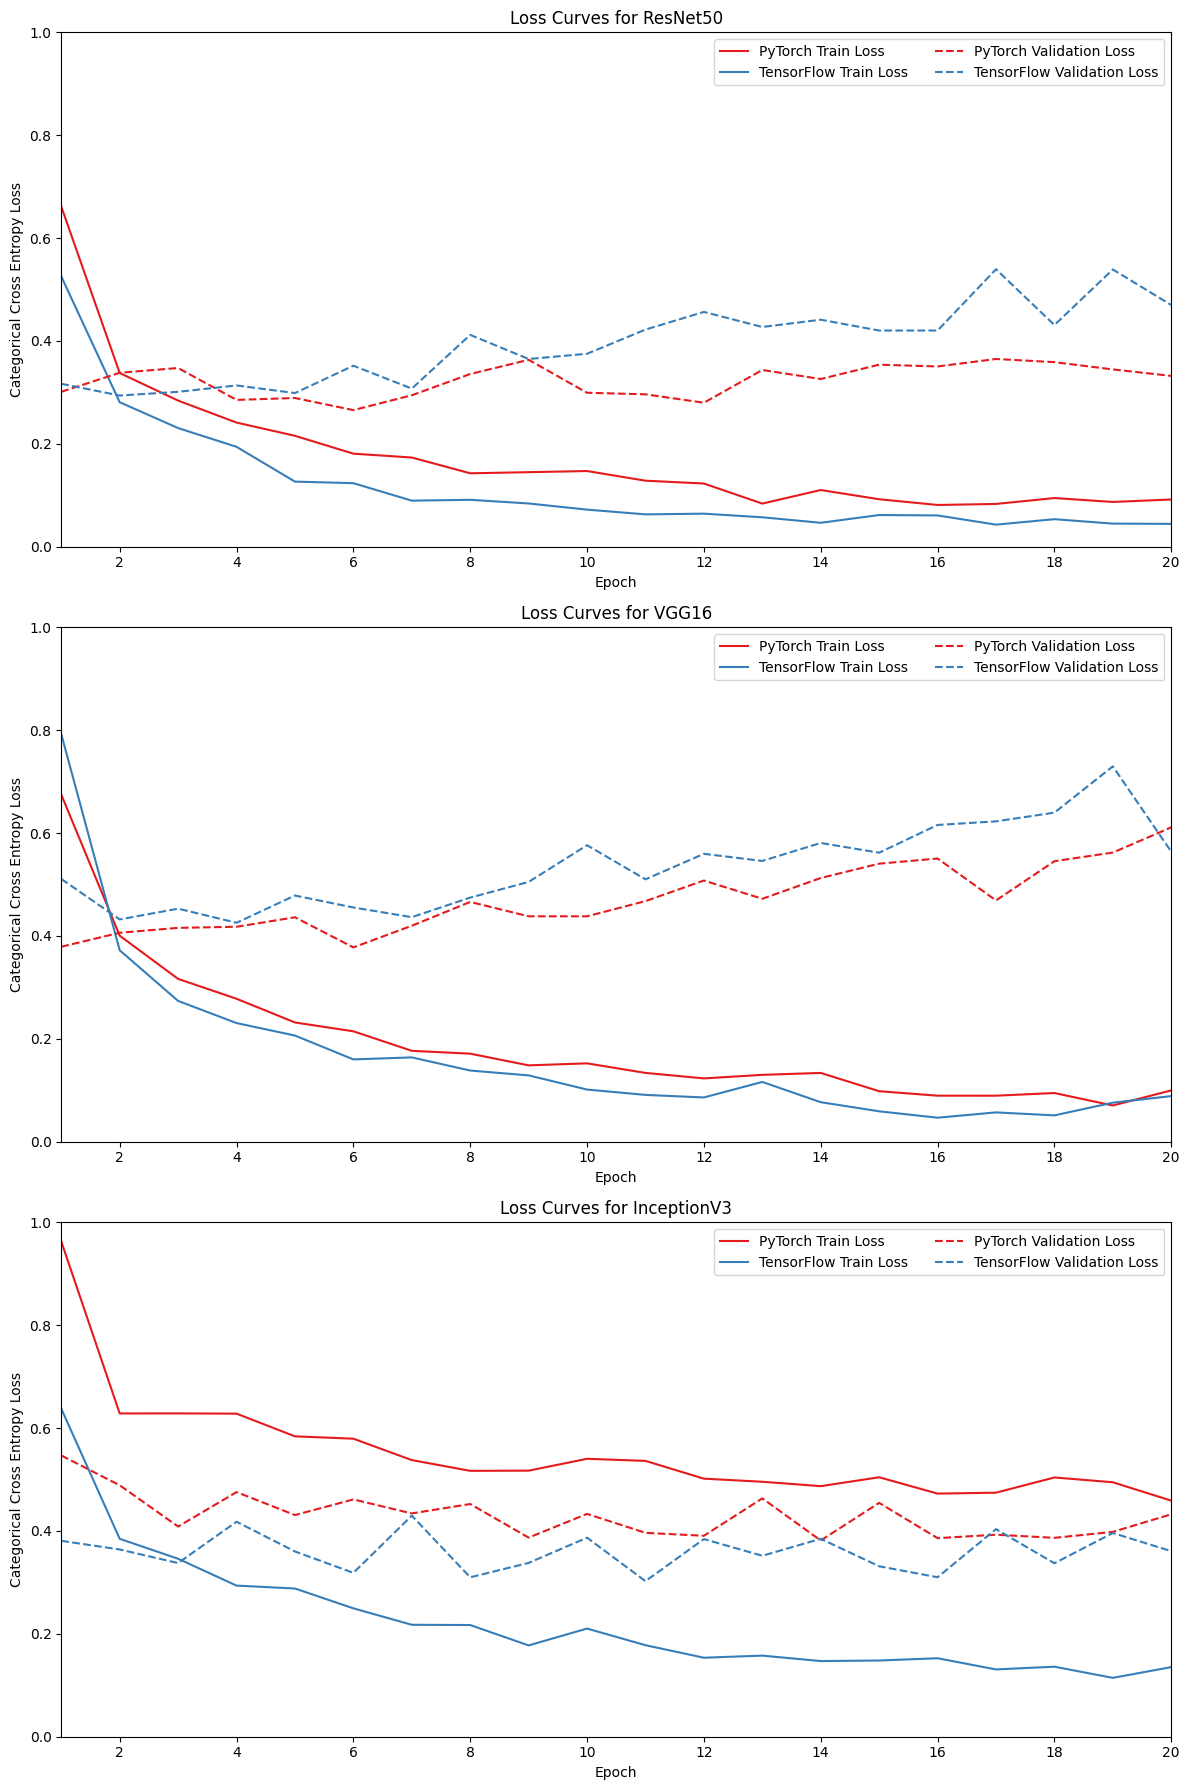

In [4]:
# Training and validation loss curves for each model under PyTorch and TensorFlow frameworks
plot_loss_curves(
    logs = logs,
    models = ['ResNet50', 'VGG16', 'InceptionV3']
);

## Classification Metrics for Each Model

Model predictions and classification metrics are only calculated for the best epoch of each of the six model-framework combinations:

- PyTorch, InceptionV3, Epoch 14
- Tensorflow, InceptionV3, Epoch 11
- PyTorch, ResNet50, Epoch 6
- Tensorflow, ResNet50, Epoch 2
- PyTorch, VGG16, Epoch 6
- Tensorflow, VGG16, Epoch 4

In [ ]:
# Directories for data and models
data_dir = '../data'
models_dir = '../models'

# Best model epochs by lowest validation scores
best_models = [
    ('inceptionv3', 'pytorch', 14),
    ('inceptionv3', 'tensorflow', 11),
    ('resnet50', 'pytorch', 6),
    ('resnet50', 'tensorflow', 2),
    ('vgg16', 'pytorch', 6),
    ('vgg16', 'tensorflow', 4)
]

In [ ]:
# Predict on test set and calculate classification metrics
classification_metrics = get_predictions_and_metrics(
    best_models = best_models,
    data_dir = data_dir,
    models_dir = models_dir
)

In [ ]:
# Save predictions and metrics for ease of loading
classification_metrics.to_csv('../predictions/model_predictions.csv', index = False)

In [5]:
# Load predictions and metrics
classification_metrics = pd.read_csv('../predictions/model_predictions.csv')

# Split into predictions and metrics for later use
predictions = classification_metrics.iloc[:, [0, 1, 2]]
metrics = classification_metrics.iloc[:, [0, 3, 4, 5, 6]]

The best model by all metrics is the InceptionV3 model under the Tensorflow implementation. Surprisingly, the InceptionV3 model is the only model with worse performance under PyTorch, all other models perform better under the PyTorch implementations. Notably, the ResNet50 PyTorch model with only 6 epochs of training performs nearly as well as the InceptionV3 Tensorflow model with 11 epochs of training. The VGG models have the worst performance and are the oldest and simplest models, both in architecture design and number of parameters. Each of the InceptionV3 (Tensorflow), ResNet50 (PyTorch), and ResNet50 (Tensorflow) achieve greater than 90% accuracy, precision, recall, and f1 score despite being fine tuned on extremely limited data (~3,237 images, ~640 per class).

Note that precision, recall, and f1-scores are calculated using macro-averages, meaning the per-class metrics are averaged assuming relative balance between the number of images for each class. There is not perfect class balance in our dataset, but it is close enough that the macro-average is reasonable to use.

In [6]:
# Metrics for each model
metrics

,model,accuracy,precision,recall,f1
0,inceptionv3_pytorch,0.865741,0.868465,0.865179,0.865003
1,inceptionv3_tensorflow,0.912963,0.912589,0.913765,0.912876
2,resnet50_pytorch,0.911111,0.913520,0.911260,0.911961
3,resnet50_tensorflow,0.902778,0.901833,0.905343,0.902781
4,vgg16_pytorch,0.877778,0.877548,0.879044,0.877465
5,vgg16_tensorflow,0.871296,0.868470,0.873852,0.870102


## Confusion Matrices for Each Model

Both versions of the ResNet50 model performed well on all classes. Both the Tensorflow and PyTorch models had a tendency to misclassify Roses and Tulips as the other class. Interestingly, the PyTorch version performed significantly better when classifying Dandelions, achieving almost perfect performance. However, by being more confident about Dandelions, the PyTorch model struggled more when classifying Tulips, sometimes predicting that Tulips and Daisies were Dandelions. The Tensorflow model had better performance on Tulips but made more mistakes when classifying Dandelions.

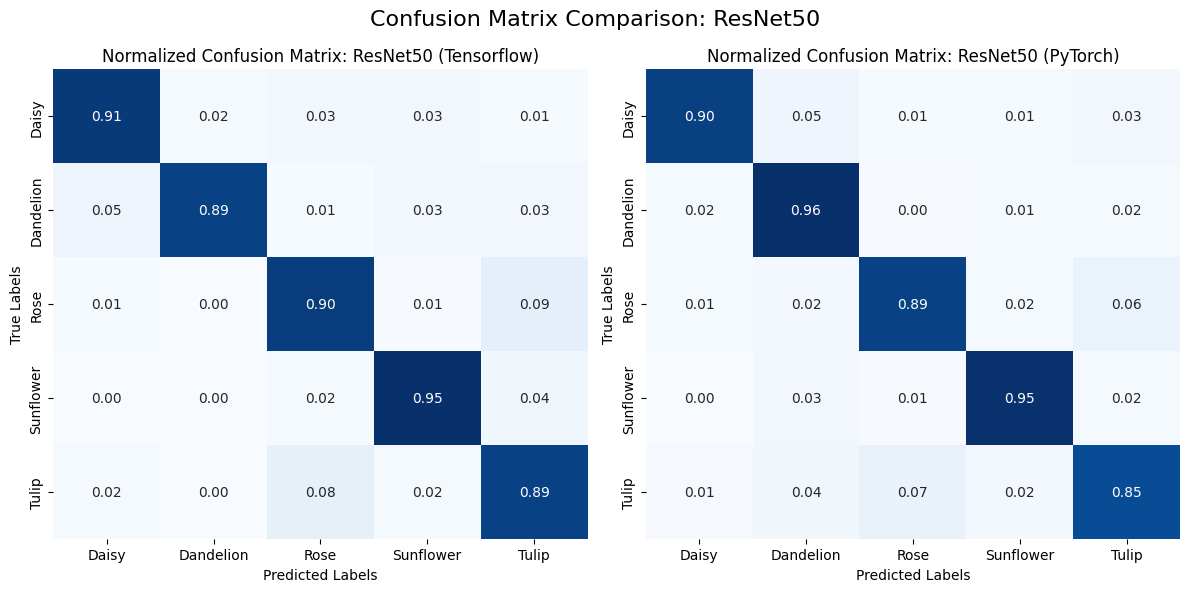

In [7]:
# Confusion matrices for Tensorflow and PyTorch on ResNet50 model
compare_confusion_matrices(
    model_name = 'ResNet50',
    inference_df = predictions,
    class_names = ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip'],
    figsize = (12, 6)
);

The VGG16 models had the worst overall performance. However, the PyTorch implementation of VGG16 had very high performance on the Daisy class. The Tensorflow implementation had better performance on the Sunflower class. Both models struggled with Roses and Tulips, just like the ResNet50 models.

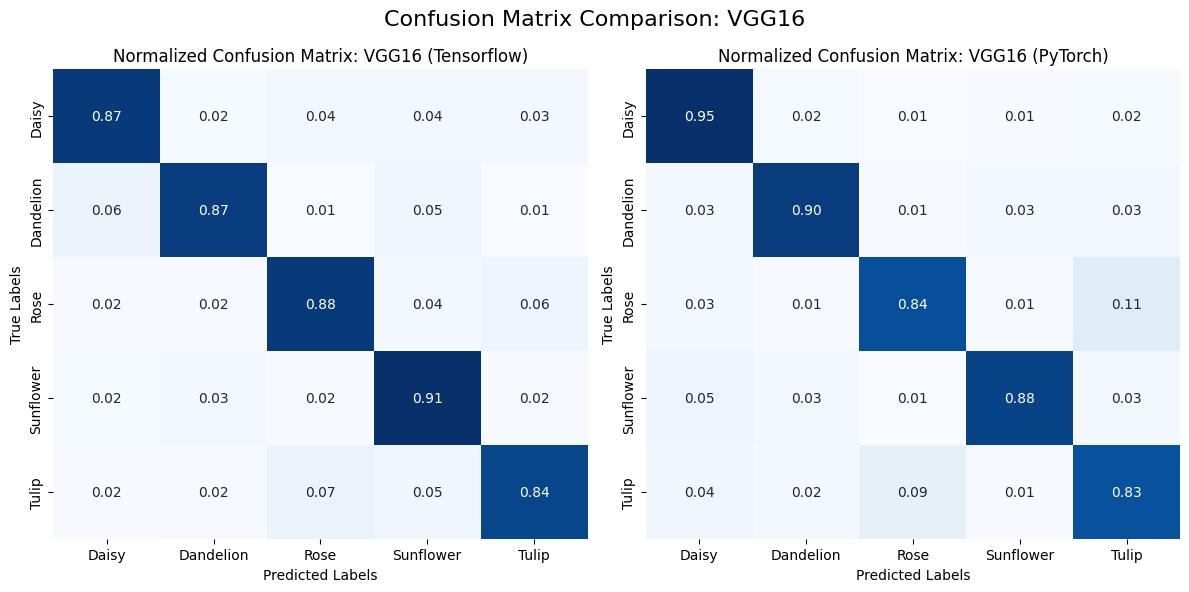

In [8]:
# Confusion matrices for Tensorflow and PyTorch on VGG16 model
compare_confusion_matrices(
    model_name = 'VGG16',
    inference_df = predictions,
    class_names = ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip'],
    figsize = (12, 6)
);

The InceptionV3 model had significantly different performances in the Tensorflow and PyTorch implementations. The Tensorflow implementation was the strongest overall model, while the PyTorch model was the weakest overall model. The PyTorch InceptionV3 model had excellent performance on Dandelions, similar to the ResNet50 model, but had significantly worse performance across other classes, especially the Tulip class. The Tensorflow InceptionV3 model has strong performance across all classes except for the Tulip class, which seems to be the most difficult class across all models, commonly being confused with Roses.

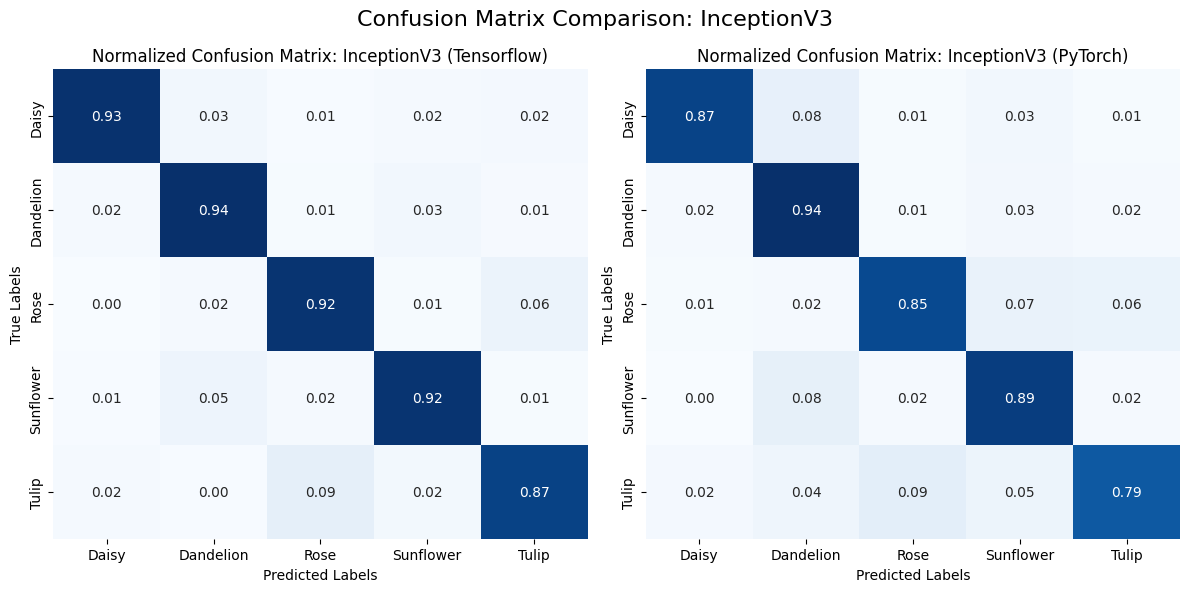

In [9]:
# Confusion matrices for Tensorflow and PyTorch on InceptionV3 model
compare_confusion_matrices(
    model_name = 'InceptionV3',
    inference_df = predictions,
    class_names = ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip'],
    figsize = (12, 6)
);

# Conclusions

Transfer learning allows for models to adapt to new datasets and related problems quickly and efficiently, dramatically reducing training time while providing high performance. Each of the models tested had tens of millions of parameters which normally would require millions of images to train. By leveraging these pre-trained models for feature extraction, we were able to achieve Accuracy, Recall, Precision, and F1-Scores above 90% with less than 20 epochs of training using a very small training dataset of 3,237 images and 5 classes. Image augmentation ensured that the models were made rotationally and spatially invariant, as well as invariant to changes in luminance or contrast.

The best performing model was the Tensorflow implementation of the InceptionV3 model. For unknown reasons, the PyTorch implementation of the InceptionV3 model severely underperformed. Both of the InceptionV3 models showed low signs of overfitting, suggesting that performance may improve with longer training times. The next best models were the ResNet50 models. Both ResNet50 models achieved performance saturation within a handful of epochs. While this means they trained faster than the InceptionV3 models, this suggests that these models reached their limit for how much they could learn from the current dataset / custom classification head architecture. The VGG16 models showed the worst performance with high overfitting, suggesting an inferior model architecture compared to the InceptionV3 and ResNet50 models, which is understandable as it was created the earliest of the three models tested.

For some reason, all of the models struggled the most with classifying Roses and Tulips, despite the flowers being quite different visually. Further attempts at improving model performance should focus on these classes. Most models were adept at identifying Dandelions and Sunflowers, which makes sense as these flowers are visually distinct. Some models struggled with Daisies, possibly due to some Daisy images having similar shapes to Sunflowers and similar coloration to Dandelions.